# 正常轴承

Successfully loaded the .mat file!
Dynamically identified sensor keys: Drive End='X100_DE_time', Fan End='X100_FE_time'

--- Analysis for SKF6205 (DE) ---
Standard Deviation of Spectrum: 0.0002
Threshold (3 * Std Dev): 0.0006
Number of significant frequency points: 1053

--- Relevant Fault Frequencies for SKF6205 (DE) (Nearest to Peaks) ---
1xBSF: 70.58 Hz
1xBPFO: 107.36 Hz
2xBSF: 141.17 Hz
1xBPFI: 162.19 Hz
3xBSF: 211.75 Hz
2xBPFO: 214.73 Hz
4xBSF: 282.34 Hz
3xBPFO: 322.09 Hz
2xBPFI: 324.37 Hz
5xBSF: 352.92 Hz
6xBSF: 423.50 Hz
4xBPFO: 429.46 Hz
3xBPFI: 486.56 Hz
7xBSF: 494.09 Hz
5xBPFO: 536.82 Hz
8xBSF: 564.67 Hz
9xBSF: 635.25 Hz
6xBPFO: 644.18 Hz
4xBPFI: 648.74 Hz
10xBSF: 705.84 Hz
7xBPFO: 751.55 Hz
11xBSF: 776.42 Hz
5xBPFI: 810.93 Hz
8xBPFO: 858.91 Hz
13xBSF: 917.59 Hz
9xBPFO: 966.28 Hz
6xBPFI: 973.12 Hz
14xBSF: 988.17 Hz
Spectrum data has been saved to SKF6205 (DE)_fft_data.csv

--- Analysis for SKF6203 (FE) ---
Standard Deviation of Spectrum: 0.0002
Threshold (3 * Std Dev): 0.0007

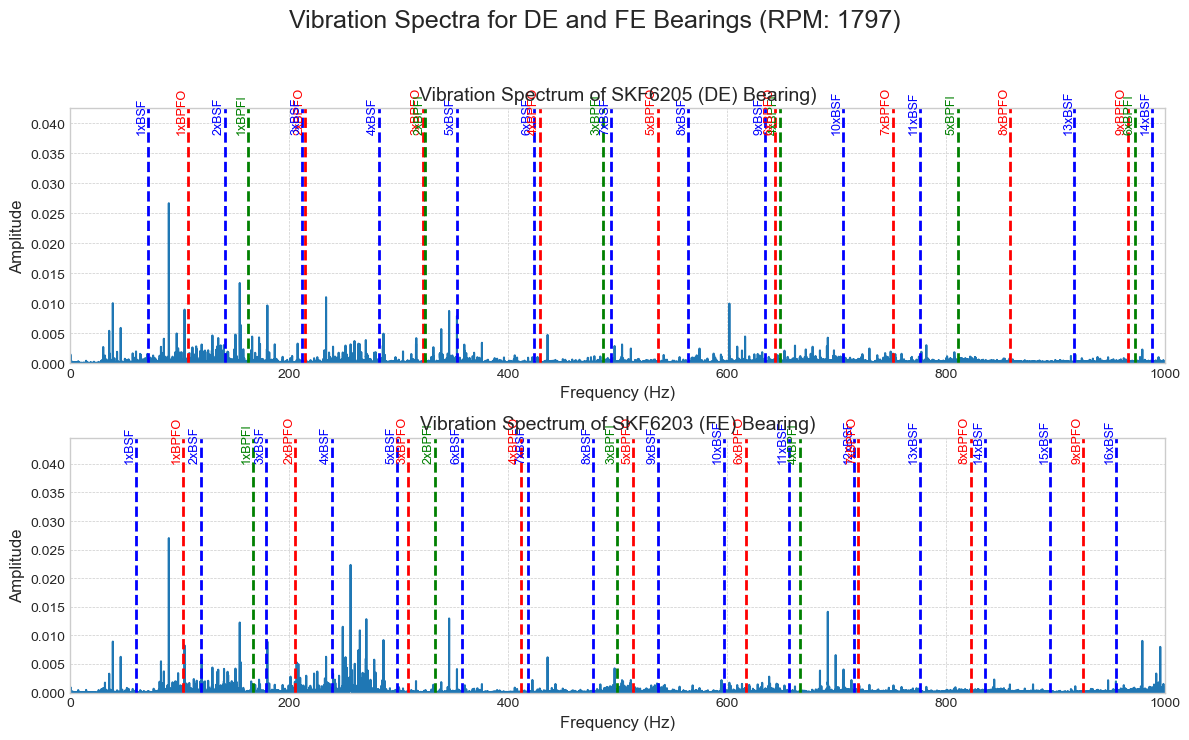


Combined plot with filtered harmonics has been saved to Combined_Final_Spectra.png


In [23]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- 1. 加载 .mat 文件并动态获取传感器键 ---
mat_file = '../data/raw/source/48kHz_Normal_data/N_3.mat'
if not os.path.exists(mat_file):
    print(f"Error: File '{mat_file}' not found. Please ensure the file is in the same directory as the script.")
    raise SystemExit

data_mat = sio.loadmat(mat_file)
print("Successfully loaded the .mat file!")

# Dynamically find the key prefix
base_key_part = next((key.split('_')[0] for key in data_mat if '_time' in key), None)
if base_key_part is None:
    print("Error: Missing time series data in the file.")
    raise SystemExit

de_key = f"{base_key_part}_DE_time"
fe_key = f"{base_key_part}_FE_time"
print(f"Dynamically identified sensor keys: Drive End='{de_key}', Fan End='{fe_key}'")

# --- 2. 定义轴承参数 ---
# Convert inches to meters (1 inch = 0.0254 m)
inch_to_m = 0.0254

# Drive End (DE) Bearing: SKF6205
params_de = {
    'name': 'SKF6205 (DE)',
    'Nb': 9.0,
    'Db': 0.3126 * inch_to_m,  # m
    'Dp': 1.537 * inch_to_m,   # m
    'alpha': 0.0,              # degrees
    'sensor_key': de_key
}

# Fan End (FE) Bearing: SKF6203
params_fe = {
    'name': 'SKF6203 (FE)',
    'Nb': 9.0,
    'Db': 0.2656 * inch_to_m,  # m
    'Dp': 1.122 * inch_to_m,   # m
    'alpha': 0.0,              # degrees
    'sensor_key': fe_key
}

# Determine sampling frequency and RPM
sampling_freq = 12000  # Hz
rpm = 1797
fr = rpm / 60

# --- 3. 定义绘图函数 ---
def plot_spectrum(ax, params, data_mat):
    """
    Plots the spectrum for a given bearing and sensor data on a specified subplot axis,
    and shows only the relevant harmonics near high-energy peaks.
    """
    sensor_data_full = data_mat[params['sensor_key']]
    sensor_data = sensor_data_full.flatten()

    # FFT
    n = len(sensor_data)
    if n % 2 != 0:
        n -= 1
        sensor_data = sensor_data[:n]

    fft_result = np.fft.fft(sensor_data)
    fft_magnitude = 2.0 / n * np.abs(fft_result[0:n//2])
    frequencies = np.fft.fftfreq(n, 1 / sampling_freq)[0:n//2]

    # Calculate standard deviation of the spectrum magnitude
    std_dev = np.std(fft_magnitude)
    threshold = 3 * std_dev
    
    # Identify frequencies with magnitude > 3x std dev
    significant_indices = np.where(fft_magnitude > threshold)[0]
    significant_frequencies = frequencies[significant_indices]

    print(f"\n--- Analysis for {params['name']} ---")
    print(f"Standard Deviation of Spectrum: {std_dev:.4f}")
    print(f"Threshold (3 * Std Dev): {threshold:.4f}")
    print(f"Number of significant frequency points: {len(significant_frequencies)}")

    # Calculate all possible characteristic frequencies and their harmonics within the range
    Nb, Db, Dp, alpha = params['Nb'], params['Db'], params['Dp'], params['alpha']
    alpha_rad = np.deg2rad(alpha)

    all_harmonics = []
    fault_types = {
        'BPFO': 0.5 * Nb * fr * (1 - (Db / Dp) * np.cos(alpha_rad)),
        'BPFI': 0.5 * Nb * fr * (1 + (Db / Dp) * np.cos(alpha_rad)),
        'BSF': 0.5 * Dp / Db * fr * (1 - (Db / Dp * np.cos(alpha_rad))**2),
    }
    
    for name, fundamental_freq in fault_types.items():
        if fundamental_freq == 0: continue
        for i in range(1, 25): # Check up to a reasonable number of harmonics
            harmonic_freq = fundamental_freq * i
            if harmonic_freq > 1000:
                break
            all_harmonics.append((name, harmonic_freq, i))

    # Identify the single closest harmonic for each significant frequency
    relevant_harmonics = set()
    for sig_freq in significant_frequencies:
        if not all_harmonics:
            continue
        # Find the harmonic with the minimum absolute difference
        min_diff = np.inf
        closest_harmonic = None
        for harmonic_name, harmonic_freq, harmonic_idx in all_harmonics:
            diff = np.abs(sig_freq - harmonic_freq)
            if diff < min_diff:
                min_diff = diff
                closest_harmonic = (harmonic_name, harmonic_freq, harmonic_idx)
        
        # Add the closest harmonic to the set
        if closest_harmonic:
            relevant_harmonics.add(closest_harmonic)

    print(f"\n--- Relevant Fault Frequencies for {params['name']} (Nearest to Peaks) ---")
    if not relevant_harmonics:
        print("No relevant harmonics found near high-energy regions.")
    else:
        for name, freq, i in sorted(list(relevant_harmonics), key=lambda x: x[1]):
            print(f"{i}x{name}: {freq:.2f} Hz")

    # Plot the full spectrum
    ax.plot(frequencies, fft_magnitude)
    ax.set_xlim(0, 1000)
    ax.set_ylim(bottom=0)
    ax.set_title(f"Vibration Spectrum of {params['name']} Bearing)", fontsize=14)
    ax.set_xlabel('Frequency (Hz)', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    colors = ['red', 'green', 'blue']
    
    # Plot only the relevant harmonics
    plotted_labels = set()
    for name, freq, i in relevant_harmonics:
        color_idx = ['BPFO', 'BPFI', 'BSF'].index(name)
        ax.axvline(x=freq, color=colors[color_idx], linestyle='--', linewidth=2)
        ax.text(freq, ax.get_ylim()[1] * 0.9, f'{i}x{name}',
                rotation=90, va='bottom', ha='right', fontsize=9, color=colors[color_idx])
    
    # Save spectrum data to a CSV file
    df_fft = pd.DataFrame({
        'Frequency (Hz)': frequencies,
        'Amplitude': fft_magnitude
    })
    csv_filename = f"../results/滤波分析/{params['name']}_fft_data.csv"
    df_fft.to_csv(csv_filename, index=False)
    print(f"Spectrum data has been saved to {csv_filename}")


# --- 4. 主程序执行 ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle(f"Vibration Spectra for DE and FE Bearings (RPM: {rpm:.0f})", fontsize=18, y=0.95)

plot_spectrum(axs[0], params_de, data_mat)
plot_spectrum(axs[1], params_fe, data_mat)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plot_filename = "../results/滤波分析/Combined_Final_Spectra.png"
plt.savefig(plot_filename)
plt.show()

print(f"\nCombined plot with filtered harmonics has been saved to {plot_filename}")

# DE端B故障

Successfully loaded the .mat file!
Dynamically identified sensor keys: Drive End='X121_DE_time', Fan End='X121_FE_time'

--- Analysis for SKF6205 (DE) ---
Standard Deviation of Spectrum: 0.0009
Threshold (3 * Std Dev): 0.0028
Number of significant frequency points: 980

--- Relevant Fault Frequencies for SKF6205 (DE) (Nearest to Peaks) ---
2xBSF: 141.17 Hz
1xBPFI: 162.19 Hz
5xBSF: 352.92 Hz
3xBPFI: 486.56 Hz
5xBPFO: 536.82 Hz
8xBSF: 564.67 Hz
9xBSF: 635.25 Hz
4xBPFI: 648.74 Hz
10xBSF: 705.84 Hz
12xBSF: 847.01 Hz
13xBSF: 917.59 Hz
14xBSF: 988.17 Hz
Spectrum data has been saved to SKF6205 (DE)_fft_data.csv

--- Analysis for SKF6203 (FE) ---
Standard Deviation of Spectrum: 0.0007
Threshold (3 * Std Dev): 0.0022
Number of significant frequency points: 275

--- Relevant Fault Frequencies for SKF6203 (FE) (Nearest to Peaks) ---
2xBSF: 119.43 Hz
1xBPFI: 166.68 Hz
3xBSF: 179.15 Hz
2xBPFI: 333.36 Hz
6xBSF: 358.29 Hz
4xBPFO: 411.48 Hz
7xBSF: 418.01 Hz
8xBSF: 477.72 Hz
5xBPFO: 514.36 Hz
9xBSF: 53

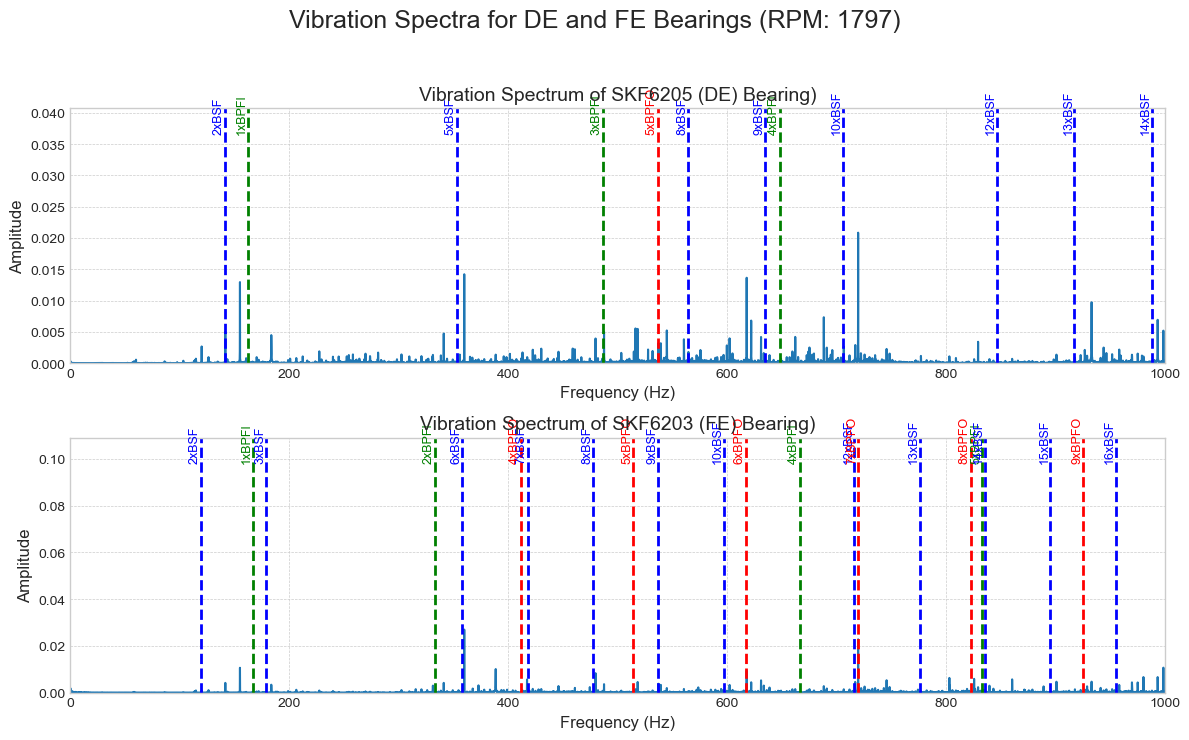


Combined plot with filtered harmonics has been saved to Combined_Final_Spectra.png


In [25]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- 1. 加载 .mat 文件并动态获取传感器键 ---
mat_file = '../data/raw/source/12kHz_DE_data/B/0007/B007_3.mat'
if not os.path.exists(mat_file):
    print(f"Error: File '{mat_file}' not found. Please ensure the file is in the same directory as the script.")
    raise SystemExit

data_mat = sio.loadmat(mat_file)
print("Successfully loaded the .mat file!")

# Dynamically find the key prefix
base_key_part = next((key.split('_')[0] for key in data_mat if '_time' in key), None)
if base_key_part is None:
    print("Error: Missing time series data in the file.")
    raise SystemExit

de_key = f"{base_key_part}_DE_time"
fe_key = f"{base_key_part}_FE_time"
print(f"Dynamically identified sensor keys: Drive End='{de_key}', Fan End='{fe_key}'")

# --- 2. 定义轴承参数 ---
# Convert inches to meters (1 inch = 0.0254 m)
inch_to_m = 0.0254

# Drive End (DE) Bearing: SKF6205
params_de = {
    'name': 'SKF6205 (DE)',
    'Nb': 9.0,
    'Db': 0.3126 * inch_to_m,  # m
    'Dp': 1.537 * inch_to_m,   # m
    'alpha': 0.0,              # degrees
    'sensor_key': de_key
}

# Fan End (FE) Bearing: SKF6203
params_fe = {
    'name': 'SKF6203 (FE)',
    'Nb': 9.0,
    'Db': 0.2656 * inch_to_m,  # m
    'Dp': 1.122 * inch_to_m,   # m
    'alpha': 0.0,              # degrees
    'sensor_key': fe_key
}

# Determine sampling frequency and RPM
sampling_freq = 12000  # Hz
rpm = 1797
fr = rpm / 60

# --- 3. 定义绘图函数 ---
def plot_spectrum(ax, params, data_mat):
    """
    Plots the spectrum for a given bearing and sensor data on a specified subplot axis,
    and shows only the relevant harmonics near high-energy peaks.
    """
    sensor_data_full = data_mat[params['sensor_key']]
    sensor_data = sensor_data_full.flatten()

    # FFT
    n = len(sensor_data)
    if n % 2 != 0:
        n -= 1
        sensor_data = sensor_data[:n]

    fft_result = np.fft.fft(sensor_data)
    fft_magnitude = 2.0 / n * np.abs(fft_result[0:n//2])
    frequencies = np.fft.fftfreq(n, 1 / sampling_freq)[0:n//2]

    # Calculate standard deviation of the spectrum magnitude
    std_dev = np.std(fft_magnitude)
    threshold = 3 * std_dev
    
    # Identify frequencies with magnitude > 3x std dev
    significant_indices = np.where(fft_magnitude > threshold)[0]
    significant_frequencies = frequencies[significant_indices]

    print(f"\n--- Analysis for {params['name']} ---")
    print(f"Standard Deviation of Spectrum: {std_dev:.4f}")
    print(f"Threshold (3 * Std Dev): {threshold:.4f}")
    print(f"Number of significant frequency points: {len(significant_frequencies)}")

    # Calculate all possible characteristic frequencies and their harmonics within the range
    Nb, Db, Dp, alpha = params['Nb'], params['Db'], params['Dp'], params['alpha']
    alpha_rad = np.deg2rad(alpha)

    all_harmonics = []
    fault_types = {
        'BPFO': 0.5 * Nb * fr * (1 - (Db / Dp) * np.cos(alpha_rad)),
        'BPFI': 0.5 * Nb * fr * (1 + (Db / Dp) * np.cos(alpha_rad)),
        'BSF': 0.5 * Dp / Db * fr * (1 - (Db / Dp * np.cos(alpha_rad))**2),
    }
    
    for name, fundamental_freq in fault_types.items():
        if fundamental_freq == 0: continue
        for i in range(1, 25): # Check up to a reasonable number of harmonics
            harmonic_freq = fundamental_freq * i
            if harmonic_freq > 1000:
                break
            all_harmonics.append((name, harmonic_freq, i))

    # Identify the single closest harmonic for each significant frequency
    relevant_harmonics = set()
    for sig_freq in significant_frequencies:
        if not all_harmonics:
            continue
        # Find the harmonic with the minimum absolute difference
        min_diff = np.inf
        closest_harmonic = None
        for harmonic_name, harmonic_freq, harmonic_idx in all_harmonics:
            diff = np.abs(sig_freq - harmonic_freq)
            if diff < min_diff:
                min_diff = diff
                closest_harmonic = (harmonic_name, harmonic_freq, harmonic_idx)
        
        # Add the closest harmonic to the set
        if closest_harmonic:
            relevant_harmonics.add(closest_harmonic)

    print(f"\n--- Relevant Fault Frequencies for {params['name']} (Nearest to Peaks) ---")
    if not relevant_harmonics:
        print("No relevant harmonics found near high-energy regions.")
    else:
        for name, freq, i in sorted(list(relevant_harmonics), key=lambda x: x[1]):
            print(f"{i}x{name}: {freq:.2f} Hz")

    # Plot the full spectrum
    ax.plot(frequencies, fft_magnitude)
    ax.set_xlim(0, 1000)
    ax.set_ylim(bottom=0)
    ax.set_title(f"Vibration Spectrum of {params['name']} Bearing)", fontsize=14)
    ax.set_xlabel('Frequency (Hz)', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    colors = ['red', 'green', 'blue']
    
    # Plot only the relevant harmonics
    plotted_labels = set()
    for name, freq, i in relevant_harmonics:
        color_idx = ['BPFO', 'BPFI', 'BSF'].index(name)
        ax.axvline(x=freq, color=colors[color_idx], linestyle='--', linewidth=2)
        ax.text(freq, ax.get_ylim()[1] * 0.9, f'{i}x{name}',
                rotation=90, va='bottom', ha='right', fontsize=9, color=colors[color_idx])
    
    # Save spectrum data to a CSV file
    df_fft = pd.DataFrame({
        'Frequency (Hz)': frequencies,
        'Amplitude': fft_magnitude
    })
    csv_filename = f"../results/滤波分析/{params['name']}_fft_data.csv"
    df_fft.to_csv(csv_filename, index=False)
    print(f"Spectrum data has been saved to {csv_filename}")


# --- 4. 主程序执行 ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle(f"Vibration Spectra for DE and FE Bearings (RPM: {rpm:.0f})", fontsize=18, y=0.95)

plot_spectrum(axs[0], params_de, data_mat)
plot_spectrum(axs[1], params_fe, data_mat)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plot_filename = "../results/滤波分析/Combined_Final_Spectra.png"
plt.savefig(plot_filename)
plt.show()

print(f"\nCombined plot with filtered harmonics has been saved to {plot_filename}")